In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timezone
from pathlib import Path
import ast
import time

In [2]:
def load_data(raw_base_path, alert_base_path, day_to_load=datetime.now(timezone.utc).strftime("%Y-%m-%d")) -> pd.DataFrame:
 
    raw_path = Path(f"{raw_base_path}/event_dt={day_to_load}")
    alert_path = Path(f"{alert_base_path}/event_dt={day_to_load}")
 
    # Load all CSVs in each partition directory
    raw_df = pd.concat(
        [pd.read_csv(f) for f in raw_path.glob("*.csv")],
        ignore_index=True,
    )
    alert_df = pd.concat(
        [pd.read_csv(f) for f in alert_path.glob("*.csv")],
        ignore_index=True,
    )
 
    # Keep only the row with the largest z-score per unique "column" value
    alert_df = (
        alert_df
        .sort_values("z_score", ascending=False)
        .drop_duplicates(subset="id")
        .reset_index(drop=True)
    )
 
    # Left join: keep all raw rows, attach alert info where available
    merged_df = alert_df.merge(raw_df, on="event_id", how="left")
 
    return merged_df


In [10]:
import matplotlib.dates as mdates


def parse_list_col(val: str, dtype=float) -> list:
    """Parse a stringified Python list into a typed list."""
    parsed = ast.literal_eval(val)
    return [dtype(v) for v in parsed]

def parse_timestamps(val: str) -> list[str]:
    """Parse a stringified list of timestamps without ast.literal_eval.
    Timestamps like '2026-04-21 02:15:00' are unquoted inside the string,
    so ast.literal_eval fails on the leading zeros in time components."""
    stripped = val.strip().lstrip("[").rstrip("]")
    return [ts.strip() for ts in stripped.split(",")]


def plot_anomalies(df: pd.DataFrame, z_threshold: float = 2.0, n_rows: int = 10):
    subset = df.head(n_rows).reset_index(drop=True)

    cols = 2
    rows = (n_rows + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
    axes = axes.flatten()

    for i, row in subset.iterrows():
        ax = axes[i]

        # --- Parse historical data ---
        prices = parse_list_col(row["past_prices"], float)
        timestamps = pd.to_datetime(
            parse_timestamps(row["past_timestamps"]), utc=True
        )

        # --- Append current data point ---
        curr_price = float(row["curr_price"])
        curr_ts = pd.to_datetime(row["event_ts_x"], utc=True)
        all_ts = list(timestamps) + [curr_ts]
        all_prices = prices + [curr_price]

        mean = float(row["mean"])
        std = float(row["std"])
        upper = mean + z_threshold * std
        lower = mean - z_threshold * std
        is_anomaly = row["z_score"] > z_threshold
        z_score = float(row["z_score"])
        symbol = row.get("symbol", f"Row {i}")
        name = row.get("name", "")

        # --- Acceptable range band ---
        ax.fill_between(
            all_ts, lower, upper,
            alpha=0.15, color="green",
            label=f"±{z_threshold}σ range"
        )
        ax.axhline(mean, color="gray", linestyle="--", linewidth=0.8, label="Mean")

        # --- Historical line ---
        ax.plot(timestamps, prices, color="steelblue", linewidth=1.5, label="Historical")

        # --- Current price point ---
        point_color = "red" if is_anomaly else "green"
        ax.scatter(
            [curr_ts], [curr_price],
            color=point_color, zorder=5, s=60,
            label=f"Current ({'anomaly' if is_anomaly else 'normal'})"
        )
        ax.annotate(
            f"z={z_score:.2f}",
            xy=(curr_ts, curr_price),
            xytext=(8, 4), textcoords="offset points",
            fontsize=8, color=point_color
        )

        # --- Formatting ---

        # Zoom out y-axis: pad to 5x the band half-width around the mean
        band_half = z_threshold * std
        y_pad = band_half * 5
        ax.set_ylim(mean - y_pad, mean + y_pad)


        ax.set_title(f"{name} ({symbol})", fontsize=11, fontweight="bold")
        ax.set_ylabel("Price (USD)")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=timezone.utc))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Price Anomaly Detection — Z-Score Bands", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(f"plots/anomaly_plot_{str(int(time.time()))}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved to anomaly_plot.png")

In [11]:
df = load_data("percent_change_1h_output/raw_output", "percent_change_1h_output/alerts", "2026-04-27")
df = df.sort_values("id_x", ascending=True)
print(df.shape)
df.head(5)


(100, 20)


,id_x,event_id,event_ts_x,curr_price,past_prices,past_timestamps,mean,std,z_score,alert_id,id_y,name,symbol,price,event_ts_y,volume_24h,volume_change_24h,percent_change_1h,percent_change_24h,processing_time
32,1,3c059d03e8de0c6ab86d8be38c332754df3f5927bb2ff5...,2026-04-27T01:57:00.000Z,-0.083099,"[0.7586744, 0.84926527, 0.76085527, 0.74861671...","[2026-04-27 00:57:00, 2026-04-27 01:02:00, 202...",0.599747,0.155125,4.401907,3c059d03e8de0c6ab86d8be38c332754df3f5927bb2ff5...,1,Bitcoin,BTC,79198.599371,2026-04-27T01:57:00.000Z,2.518527e+10,55.8851,-0.083099,2.214929,2026-04-27T21:04:46.877Z
99,2,855ac51830aa923b1c83a92d0e1988f909cebadb8e7680...,2026-04-27T01:02:00.000Z,0.313240,"[0.14623433, 0.26062105, 0.16593017, 0.0964788...","[2026-04-27 00:02:00, 2026-04-27 00:07:00, 202...",0.026864,0.130619,2.192460,855ac51830aa923b1c83a92d0e1988f909cebadb8e7680...,2,Litecoin,LTC,56.489302,2026-04-27T01:02:00.000Z,2.093107e+08,14.4739,0.313240,0.896764,2026-04-27T21:04:46.877Z
17,52,59fe8225ec630ff7dfb9d8f36e3f5a17e0d08c4de3cd7a...,2026-04-27T02:02:00.000Z,0.282595,"[0.61282368, 0.7141777, 0.65427887, 0.69275375...","[2026-04-27 01:02:00, 2026-04-27 01:07:00, 202...",0.696840,0.084232,4.917888,59fe8225ec630ff7dfb9d8f36e3f5a17e0d08c4de3cd7a...,52,XRP,XRP,1.444808,2026-04-27T02:02:00.000Z,1.392433e+09,30.8433,0.282595,1.742463,2026-04-27T21:04:46.877Z
7,74,06828fc07ffab2b599e8df85e09ef8debda50874438f42...,2026-04-27T01:02:00.000Z,0.739382,"[0.12494208, 0.286822, 0.27892548, 0.19435438,...","[2026-04-27 00:02:00, 2026-04-27 00:07:00, 202...",0.108196,0.115572,5.461405,06828fc07ffab2b599e8df85e09ef8debda50874438f42...,74,Dogecoin,DOGE,0.100017,2026-04-27T01:02:00.000Z,1.085508e+09,21.2274,0.739382,2.211758,2026-04-27T21:04:46.877Z
71,131,1f2bd3f1d312f7af9a3b7798791c2d70f6aaba8819b2e5...,2026-04-27T01:02:00.000Z,1.447388,"[-0.24004658, 0.02887815, 0.19059354, 0.180577...","[2026-04-27 00:02:00, 2026-04-27 00:07:00, 202...",0.375160,0.331249,3.236923,1f2bd3f1d312f7af9a3b7798791c2d70f6aaba8819b2e5...,131,Dash,DASH,36.830626,2026-04-27T01:02:00.000Z,6.491219e+07,19.0864,1.447388,2.067872,2026-04-27T21:04:46.877Z


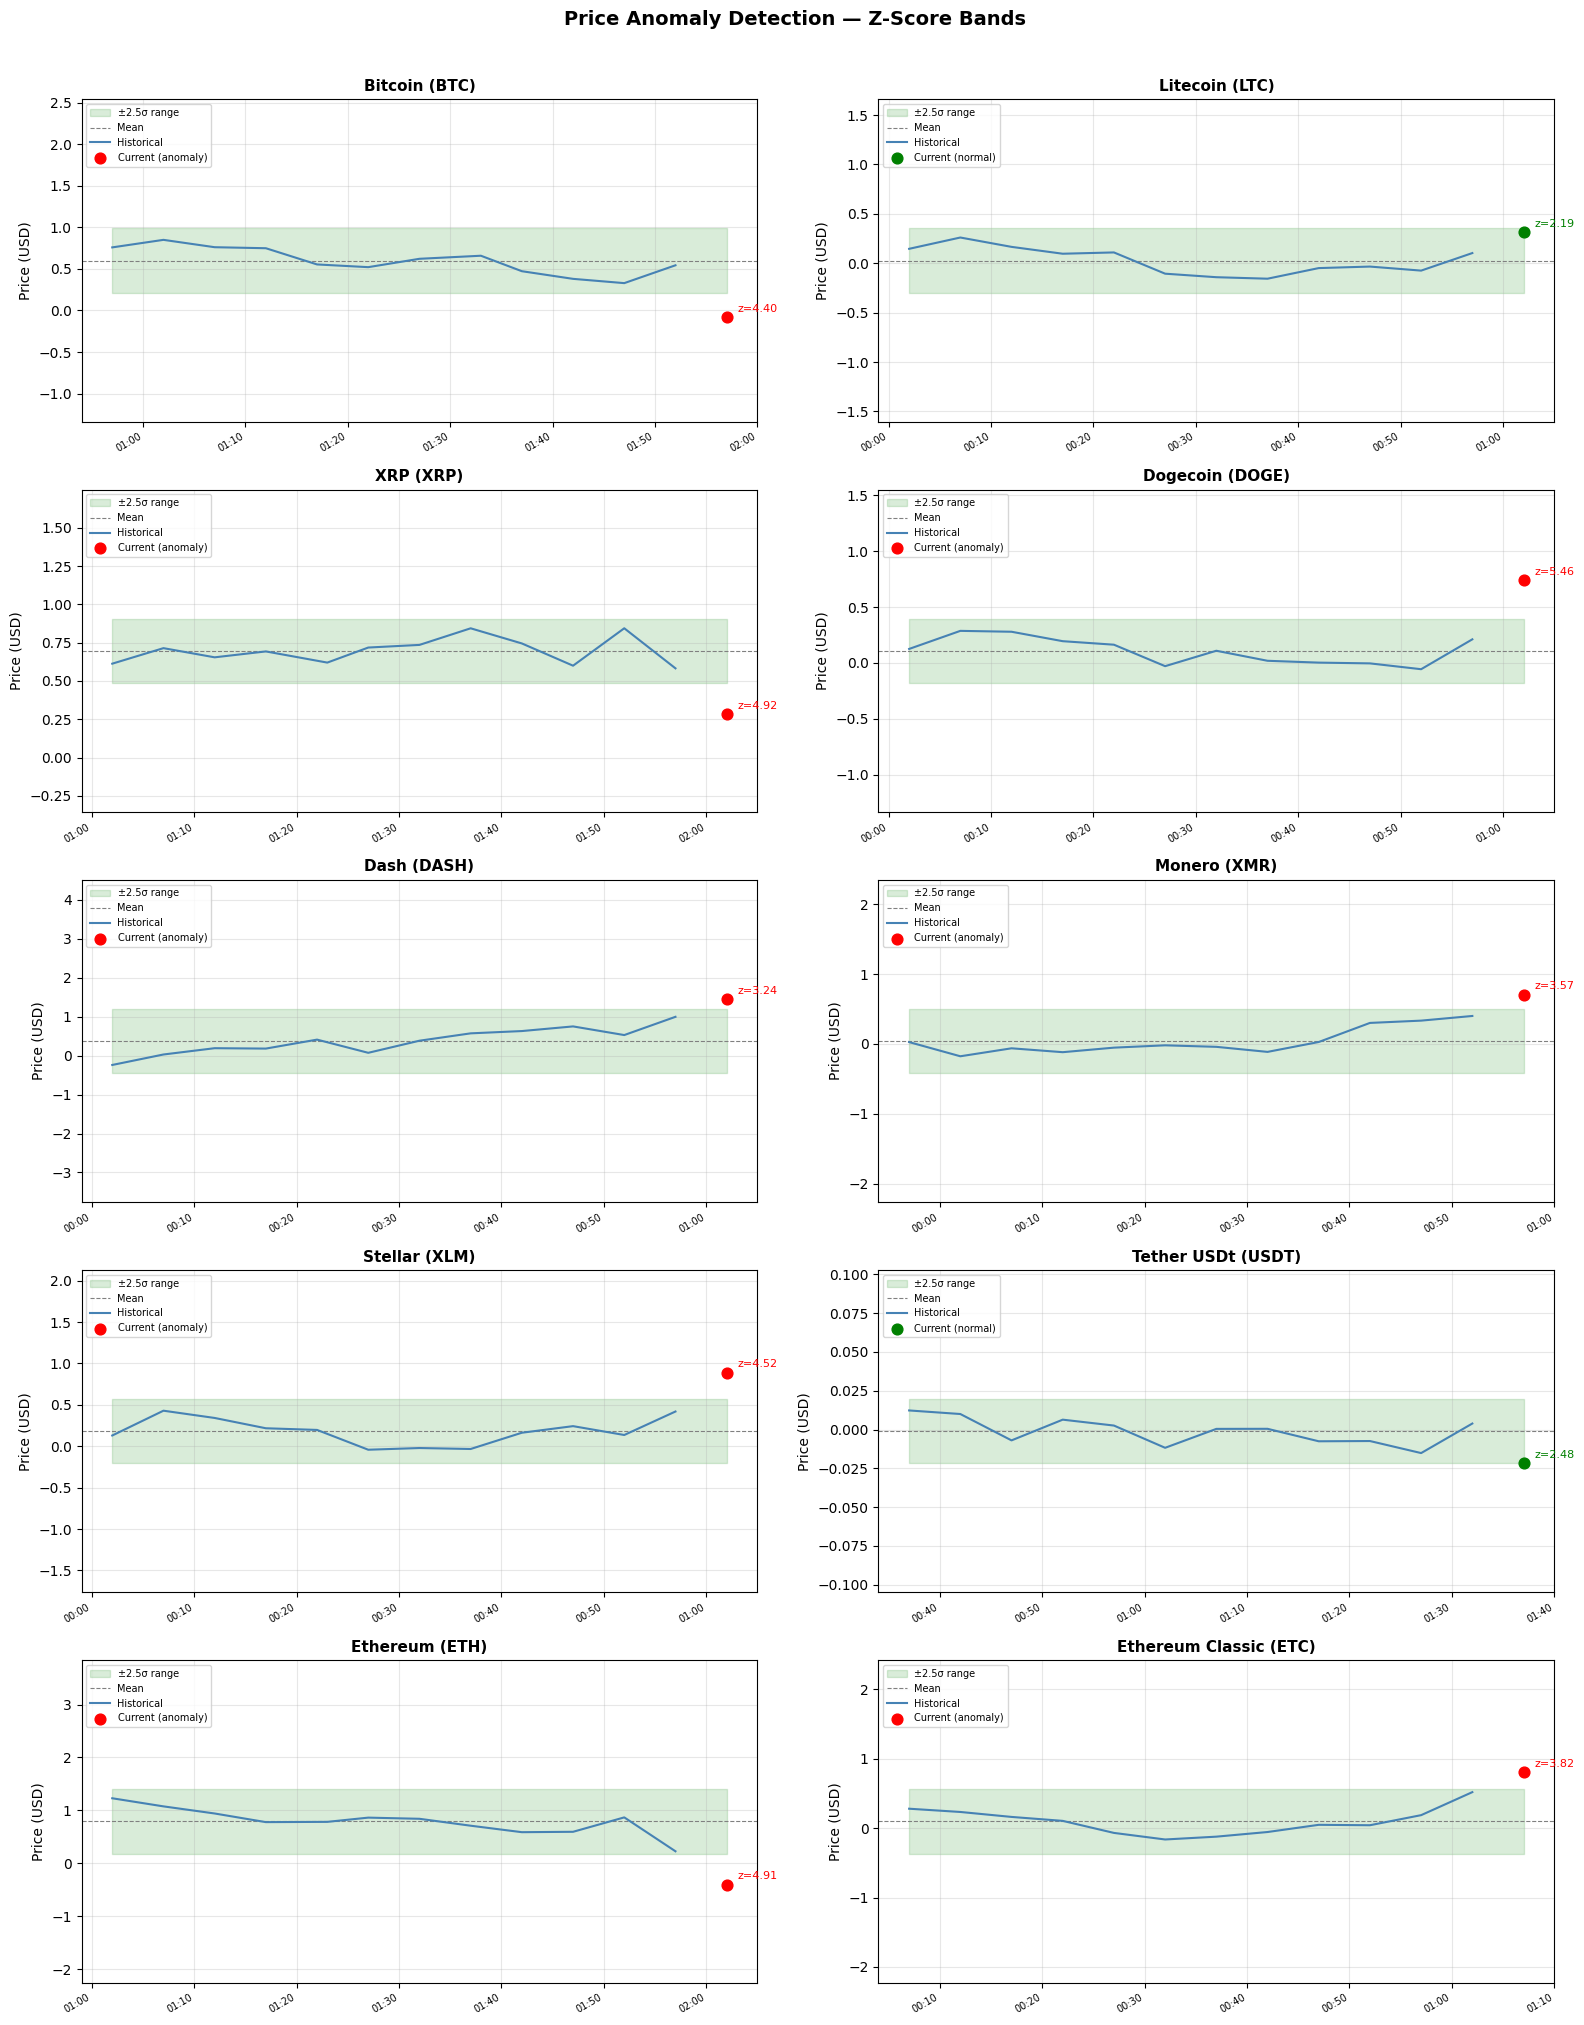

Plot saved to anomaly_plot.png


In [12]:
plot_anomalies(df, z_threshold=2.5)
